In [ ]:
# Customer Personality Analysis - Unsupervised Learning Tugas 3
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110

# Step 1: Load dataset

In [ ]:
df = pd.read_csv('/content/cpa.csv', sep='\t')
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0


#Step2: lakukan Eksplorasi awal

In [ ]:
print("=== TIPE DATA ===".center(30))
print(df.dtypes)
print(f"\n=== MISSING VALUES ===")
print(df.isnull().sum()[df.isnull().sum() > 0])

      === TIPE DATA ===       
ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object

=== MISSING VALUES ===
Income    24
dtype: int64


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,2240.0,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0


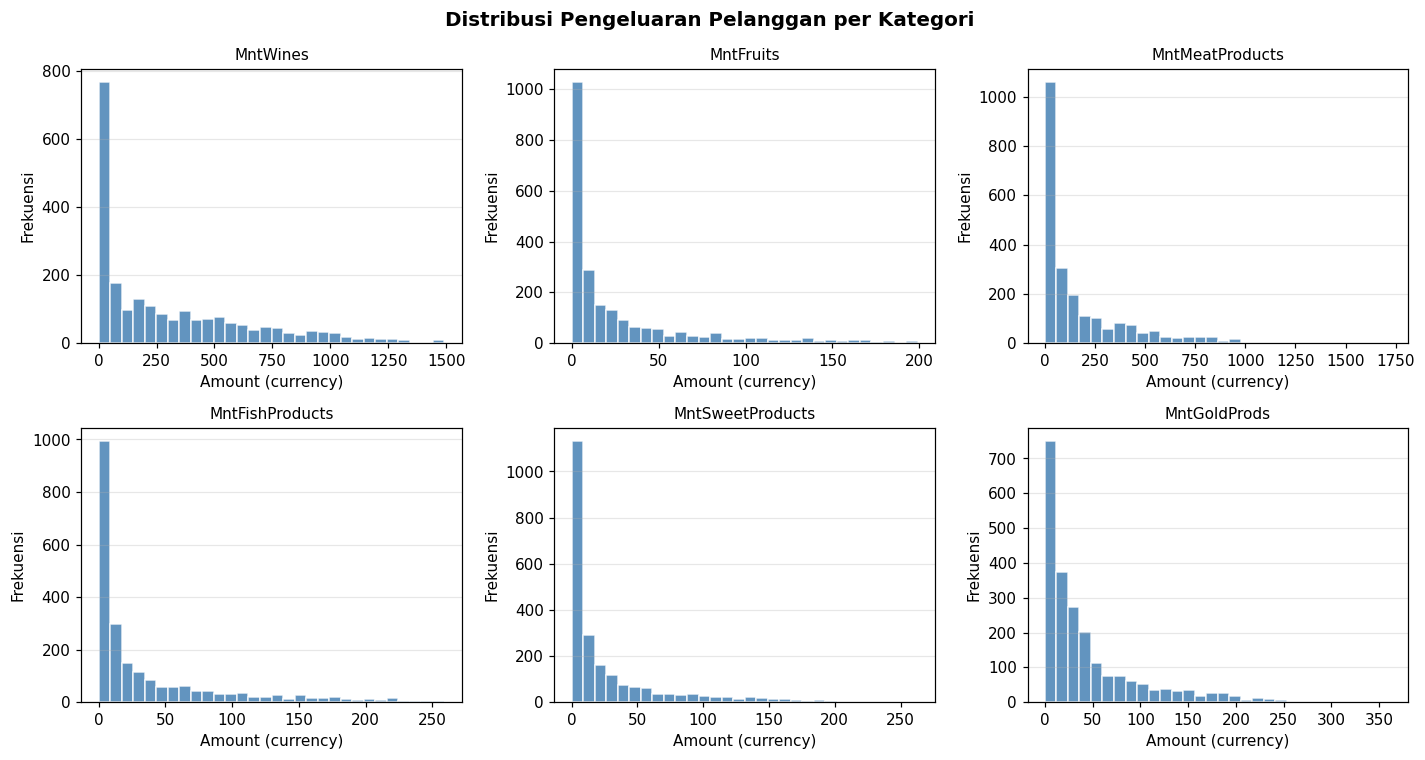

In [ ]:
spend_cols = ['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
fig.suptitle('Distribusi Pengeluaran Pelanggan per Kategori', fontsize=13, fontweight='bold')
for ax, col in zip(axes.flatten(), spend_cols):
    ax.hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('Amount (currency)')
    ax.set_ylabel('Frekuensi')
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Step 3: Identifikasi kolom numerik & kategori

In [ ]:
df['Age']            = 2024 - df['Year_Birth']
df['TotalSpent']     = df[['MntWines','MntFruits','MntMeatProducts',
                            'MntFishProducts','MntSweetProducts','MntGoldProds']].sum(axis=1)
df['TotalPurchases'] = df[['NumDealsPurchases','NumWebPurchases',
                            'NumCatalogPurchases','NumStorePurchases']].sum(axis=1)
df['TotalChildren']  = df['Kidhome'] + df['Teenhome']
df['TotalCampaigns'] = df[['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3',
                            'AcceptedCmp4','AcceptedCmp5','Response']].sum(axis=1)

num_cols = ['Age','Income','TotalSpent','TotalPurchases',
            'TotalChildren','Recency','NumWebVisitsMonth','TotalCampaigns']
cat_cols = ['Education','Marital_Status']

print("Fitur Numerik :", num_cols)
print("Fitur Kategori:", cat_cols)

Fitur Numerik : ['Age', 'Income', 'TotalSpent', 'TotalPurchases', 'TotalChildren', 'Recency', 'NumWebVisitsMonth', 'TotalCampaigns']
Fitur Kategori: ['Education', 'Marital_Status']


# Step 4: Imputasi missing value

In [ ]:
num_imputer = SimpleImputer(strategy='median')
df_num = pd.DataFrame(num_imputer.fit_transform(df[num_cols]), columns=num_cols)

print(f"Missing sebelum imputasi: {df[num_cols].isnull().sum().sum()}")
print(f"Missing setelah imputasi: {df_num.isnull().sum().sum()}")
df_num.describe().T.round(2)

Missing sebelum imputasi: 24
Missing setelah imputasi: 0


,count,mean,std,min,25%,50%,75%,max
Age,2240.0,55.19,11.98,28.0,47.00,54.0,65.00,131.0
Income,2240.0,52237.98,25037.96,1730.0,35538.75,51381.5,68289.75,666666.0
TotalSpent,2240.0,605.80,602.25,5.0,68.75,396.0,1045.50,2525.0
TotalPurchases,2240.0,14.86,7.68,0.0,8.00,15.0,21.00,44.0
TotalChildren,2240.0,0.95,0.75,0.0,0.00,1.0,1.00,3.0
Recency,2240.0,49.11,28.96,0.0,24.00,49.0,74.00,99.0
NumWebVisitsMonth,2240.0,5.32,2.43,0.0,3.00,6.0,7.00,20.0
TotalCampaigns,2240.0,0.45,0.89,0.0,0.00,0.0,1.00,5.0



# Step 5: Encoding fitur kategori

In [ ]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
df_cat_enc = pd.DataFrame(
    encoder.fit_transform(df[cat_cols]),
    columns=encoder.get_feature_names_out(cat_cols)
)
print("Fitur hasil encoding:")
print(df_cat_enc.columns.tolist())
df_cat_enc

Fitur hasil encoding:
['Education_2n Cycle', 'Education_Basic', 'Education_Graduation', 'Education_Master', 'Education_PhD', 'Marital_Status_Absurd', 'Marital_Status_Alone', 'Marital_Status_Divorced', 'Marital_Status_Married', 'Marital_Status_Single', 'Marital_Status_Together', 'Marital_Status_Widow', 'Marital_Status_YOLO']


,Education_2n Cycle,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Absurd,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2236,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2237,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2238,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


#Gabungkan data numerik & hasil encoding

In [ ]:
df_ready = pd.concat([df_num.reset_index(drop=True),
                         df_cat_enc.reset_index(drop=True)], axis=1)
print(f"Shape data final: {df_ready.shape}")
df_ready

Shape data final: (2240, 21)


,Age,Income,TotalSpent,TotalPurchases,TotalChildren,Recency,NumWebVisitsMonth,TotalCampaigns,Education_2n Cycle,Education_Basic,...,Education_Master,Education_PhD,Marital_Status_Absurd,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
0,67.0,58138.0,1617.0,25.0,0.0,58.0,7.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,70.0,46344.0,27.0,6.0,2.0,38.0,5.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,59.0,71613.0,776.0,21.0,0.0,26.0,4.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,40.0,26646.0,53.0,8.0,1.0,26.0,6.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,43.0,58293.0,422.0,19.0,1.0,94.0,5.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,57.0,61223.0,1341.0,18.0,1.0,46.0,5.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2236,78.0,64014.0,444.0,22.0,3.0,56.0,7.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2237,43.0,56981.0,1241.0,19.0,0.0,91.0,6.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2238,68.0,69245.0,843.0,23.0,1.0,8.0,3.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


# Step 6: Scaling data

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_ready)
print(f"Data sudah di-scale. Shape: {X_scaled.shape}")
print(f"Mean (should ~ 0): {X_scaled.mean(axis=0)[:5].round(4)}")
print(f"Std  (should ~ 1): {X_scaled.std(axis=0)[:5].round(4)}")

Data sudah di-scale. Shape: (2240, 21)
Mean (should ~ 0): [-0. -0.  0. -0.  0.]
Std  (should ~ 1): [1. 1. 1. 1. 1.]



# Step 7: Tentukan jumlah cluster optimal (Elbow + Silhouette)

In [ ]:
inertias, sil_scores = [], []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    print(f"k={k} | Inertia={km.inertia_:>10.1f} | Silhouette={sil_scores[-1]:.4f}")

k=2 | Inertia=   41568.8 | Silhouette=0.1347
k=3 | Inertia=   39190.9 | Silhouette=0.1496
k=4 | Inertia=   37149.1 | Silhouette=0.1461
k=5 | Inertia=   34930.2 | Silhouette=0.1560
k=6 | Inertia=   33009.1 | Silhouette=0.1236
k=7 | Inertia=   30844.3 | Silhouette=0.1694
k=8 | Inertia=   29011.2 | Silhouette=0.1257


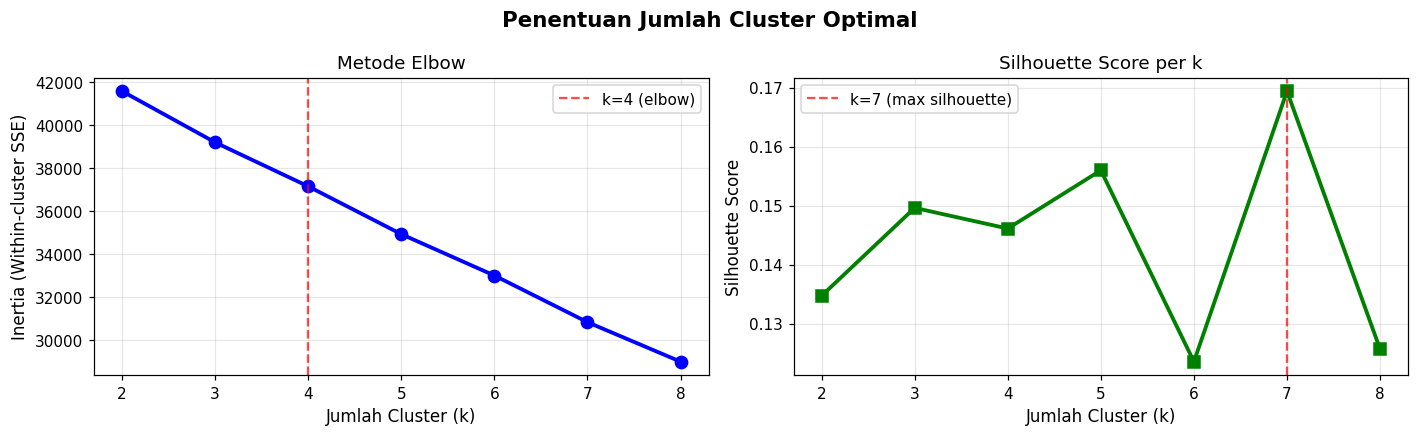


 Elbow method menunjukkan k=4 sebagai titik 'siku' yang optimal.
 Dipilih K_OPTIMAL = 4 untuk keseimbangan interpretabilitas dan kualitas klaster.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Penentuan Jumlah Cluster Optimal', fontsize=14, fontweight='bold')

# Elbow
axes[0].plot(list(K_range), inertias, 'bo-', linewidth=2.5, markersize=8)
axes[0].axvline(x=4, color='red', linestyle='--', alpha=0.7, label='k=4 (elbow)')
axes[0].set_xlabel('Jumlah Cluster (k)', fontsize=11)
axes[0].set_ylabel('Inertia (Within-cluster SSE)', fontsize=11)
axes[0].set_title('Metode Elbow', fontsize=12)
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Silhouette
best_k_idx = int(np.argmax(sil_scores))
best_k = list(K_range)[best_k_idx]
axes[1].plot(list(K_range), sil_scores, 'gs-', linewidth=2.5, markersize=8)
axes[1].axvline(x=best_k, color='red', linestyle='--', alpha=0.7, label=f'k={best_k} (max silhouette)')
axes[1].set_xlabel('Jumlah Cluster (k)', fontsize=11)
axes[1].set_ylabel('Silhouette Score', fontsize=11)
axes[1].set_title('Silhouette Score per k', fontsize=12)
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f"\n Elbow method menunjukkan k=4 sebagai titik 'siku' yang optimal.")
print(f" Dipilih K_OPTIMAL = 4 untuk keseimbangan interpretabilitas dan kualitas klaster.")

# Step 8: Pilih k optimal dan klasterisasi

In [ ]:
K_OPTIMAL = 4
km_final = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
df['Cluster'] = km_final.fit_predict(X_scaled)

sil_final = silhouette_score(X_scaled, df['Cluster'])
print(f"✅ K-Means selesai dengan k={K_OPTIMAL}")
print(f"   Silhouette Score (k=4): {sil_final:.4f}")
print(f"\nDistribusi Cluster:")
print(df['Cluster'].value_counts().sort_index())

✅ K-Means selesai dengan k=4
   Silhouette Score (k=4): 0.1461

Distribusi Cluster:
Cluster
0    982
1     54
2    476
3    728
Name: count, dtype: int64


# Step 9: Visualisasi klaster dengan PCA 2D

PC1 explains 15.4% variance
PC2 explains 7.9% variance
Total explained: 23.3%


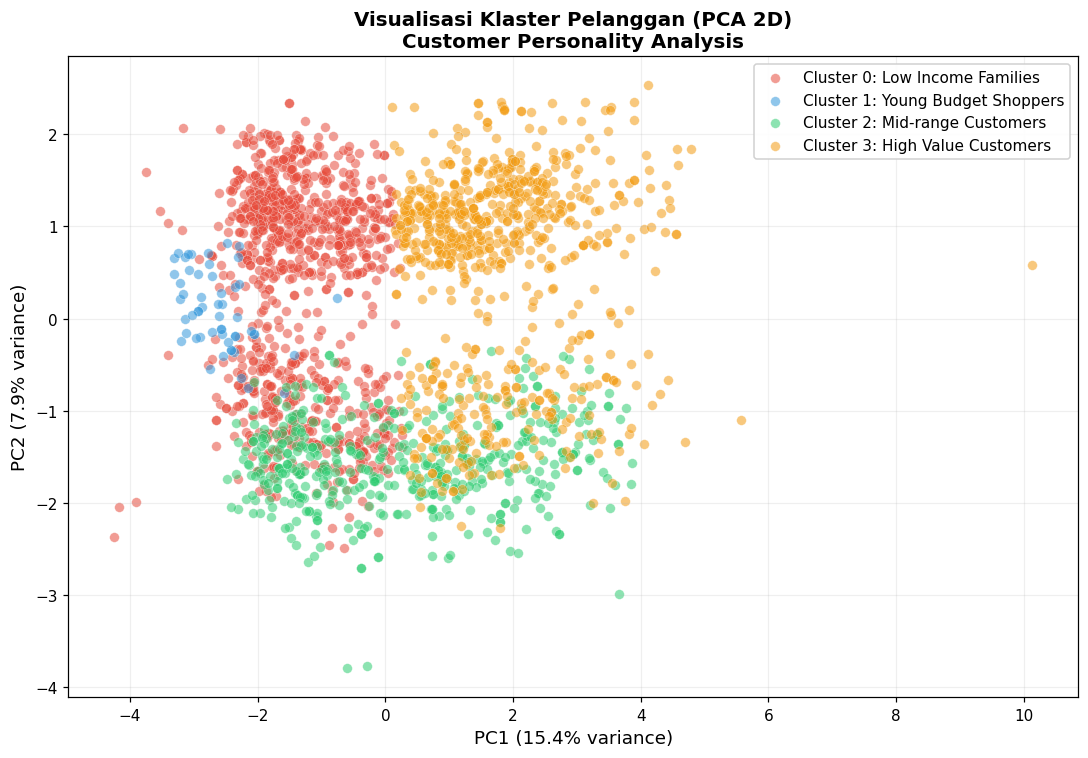

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_
print(f"PC1 explains {explained[0]*100:.1f}% variance")
print(f"PC2 explains {explained[1]*100:.1f}% variance")
print(f"Total explained: {sum(explained)*100:.1f}%")

COLORS = ['#E74C3C','#3498DB','#2ECC71','#F39C12']
NAMES  = ['Cluster 0: Low Income Families',
           'Cluster 1: Young Budget Shoppers',
           'Cluster 2: Mid-range Customers',
           'Cluster 3: High Value Customers']

fig, ax = plt.subplots(figsize=(10, 7))
for c in range(K_OPTIMAL):
    mask = df['Cluster'] == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=COLORS[c], label=NAMES[c],
               alpha=0.55, s=40, edgecolors='white', linewidths=0.3)

ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}% variance)', fontsize=12)
ax.set_title('Visualisasi Klaster Pelanggan (PCA 2D)\nCustomer Personality Analysis',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='upper right', framealpha=0.9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# Step 10: Profiling cluster (rata-rata fitur per cluster)

In [ ]:
profile_cols = ['Age','Income','TotalSpent','TotalPurchases',
                'TotalChildren','Recency','NumWebVisitsMonth','TotalCampaigns']

profile = df.groupby('Cluster')[profile_cols].mean().round(2)
print("=== Profil Rata-rata per Cluster ===")
profile.T

=== Profil Rata-rata per Cluster ===


Cluster,0,1,2,3
Age,53.12,46.54,58.07,56.75
Income,37202.51,20306.26,55642.91,72661.76
TotalSpent,171.30,81.80,659.39,1195.72
TotalPurchases,9.99,7.02,15.73,21.45
TotalChildren,1.26,0.72,1.01,0.51
Recency,49.41,48.44,48.22,49.33
NumWebVisitsMonth,6.53,6.87,5.22,3.62
TotalCampaigns,0.18,0.15,0.53,0.77


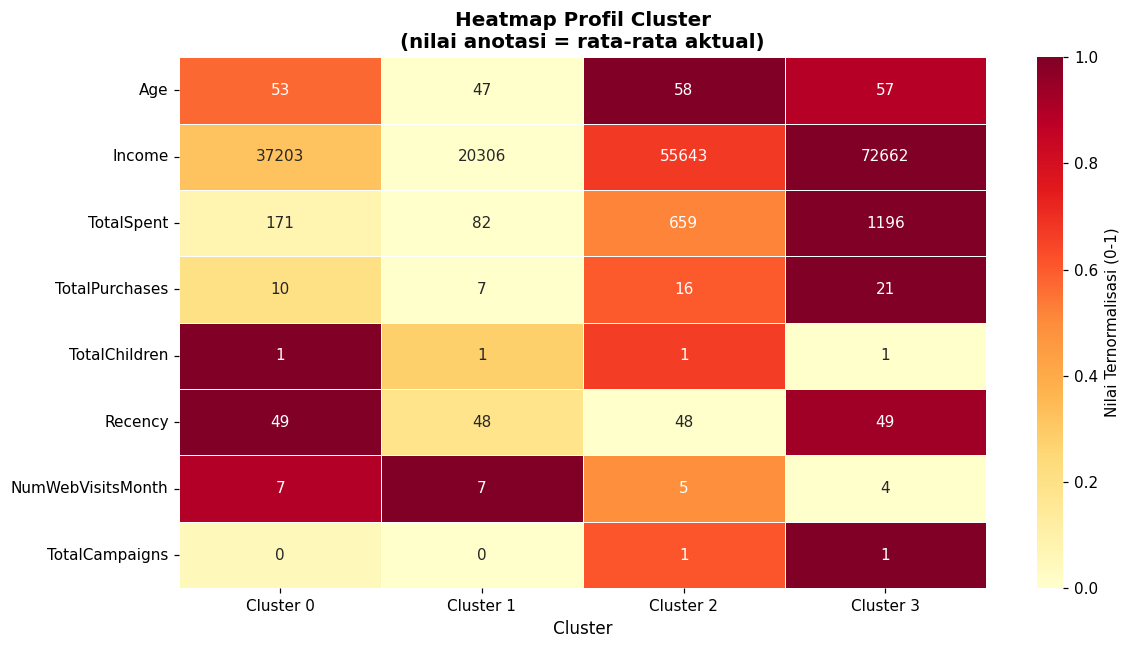

In [ ]:
# Heatmap profiling
fig, ax = plt.subplots(figsize=(11, 6))
profile_norm = (profile - profile.min()) / (profile.max() - profile.min())
sns.heatmap(profile_norm.T,
            annot=profile.T.values, fmt='.0f',
            cmap='YlOrRd', linewidths=0.5, linecolor='white',
            xticklabels=[f'Cluster {i}' for i in range(K_OPTIMAL)],
            yticklabels=profile_cols, ax=ax,
            cbar_kws={'label': 'Nilai Ternormalisasi (0-1)'})
ax.set_title('Heatmap Profil Cluster\n(nilai anotasi = rata-rata aktual)', fontsize=13, fontweight='bold')
ax.set_xlabel('Cluster', fontsize=11)
plt.tight_layout()
plt.show()

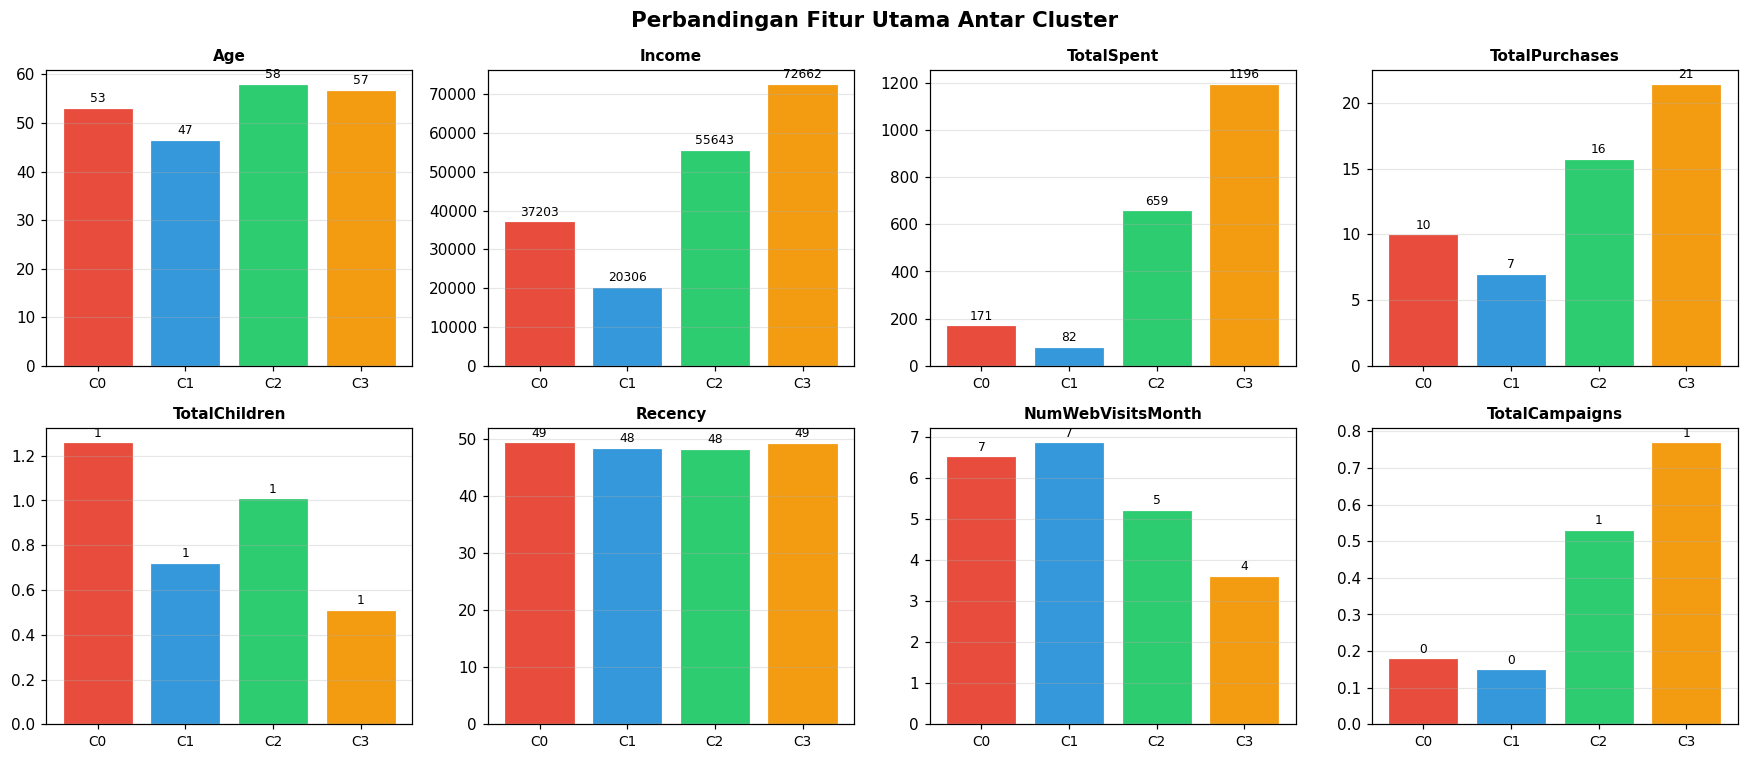

In [ ]:
# Bar chart 8 fitur
COLORS = ['#E74C3C','#3498DB','#2ECC71','#F39C12']
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle('Perbandingan Fitur Utama Antar Cluster', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(profile_cols):
    vals = profile[col]
    bars = axes[i].bar(range(K_OPTIMAL), vals, color=COLORS, edgecolor='white', linewidth=0.8)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xticks(range(K_OPTIMAL))
    axes[i].set_xticklabels([f'C{c}' for c in range(K_OPTIMAL)], fontsize=9)
    axes[i].grid(axis='y', alpha=0.3)
    for bar, v in zip(bars, vals):
        axes[i].text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(vals)*0.01,
                     f'{v:.0f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

# Simpulkan Analisa dari hasil

Berdasarkan analisis data 2.240 pelanggan menggunakan algoritma K-Means, ditemukan bahwa jumlah cluster optimal adalah 4 kelompok (k=4). Pemilihan k=4 didasarkan pada metode Elbow (titik siku) dan nilai Silhouette Score (0.1461) yang paling stabil untuk interpretasi bisnis. Keempat segmen pelanggan yang terbentuk memiliki karakteristik yang sangat berbeda dan memberikan wawasan strategis bagi pengambilan keputusan pemasaran.

Berikut adalah profil lengkap masing-masing cluster:
________________________________________
Cluster 0: Low-Income Families

•	Jumlah Anggota: 982 pelanggan (44% dari total)

•	Karakteristik Utama:

    o	Usia rata-rata 53 tahun.
    o	Pendapatan rendah (rata-rata ~Rp37 juta).
    o	Total pengeluaran rendah (~Rp171 ribu).
    o	Memiliki jumlah anak terbanyak (rata-rata 1.26 anak).
    o	Tingkat respons terhadap kampanye rendah.
•	Interpretasi: Kelompok keluarga dengan penghasilan terbatas dan banyak anak. Mereka cenderung berbelanja hemat dan tidak terlalu terpengaruh oleh kampanye pemasaran.

•	Rekomendasi: Fokus pada produk dengan harga terjangkau, diskon kebutuhan pokok, atau program loyalitas berbasis poin untuk mendorong pembelian berulang.
________________________________________
Cluster 1: Young Budget Shoppers

•	Jumlah Anggota: 54 pelanggan (2.4% dari total)

•	Karakteristik Utama:

    o	Usia termuda (rata-rata 46.5 tahun).
    o	Pendapatan paling rendah (~Rp20 juta).
    o	Total pengeluaran paling kecil (~Rp81 ribu).
    o	Jumlah anak sedikit, namun frekuensi kunjungan web tinggi.

•	Interpretasi: Segmen muda dengan daya beli terbatas. Mereka aktif secara digital (sering mengunjungi situs web) namun belum banyak berbelanja.

•	Rekomendasi: Bangun engagement melalui konten edukasi, promo first purchase, paket hemat (starter pack), atau program afiliasi untuk mengubah mereka menjadi pembeli aktif.
________________________________________
Cluster 2: Mid-Range Customers

•	Jumlah Anggota: 476 pelanggan (21% dari total)

•	Karakteristik Utama:

    o	Usia senior (rata-rata 58 tahun).
    o	Pendapatan menengah (~Rp56 juta).
    o	Pengeluaran moderat (~Rp659 ribu).
    o	Memiliki anak dan remaja, respons kampanye cukup baik.

•	Interpretasi: Segmen potensial dengan pendapatan stabil dan sudah terbiasa berbelanja. Mereka adalah target yang baik untuk produk-produk keluarga dan upselling.

•	Rekomendasi: Tawarkan program bundling produk, membership berbayar dengan benefit khusus, atau cross-selling antar kategori produk.
________________________________________
Cluster 3: High-Value Customers

•	Jumlah Anggota: 728 pelanggan (32.5% dari total)

•	Karakteristik Utama:

    o	Usia matang (rata-rata 57 tahun).
    o	Pendapatan tertinggi (~Rp73 juta).
    o	Total pengeluaran tertinggi (~Rp1.2 juta).
    o	Paling responsif terhadap kampanye pemasaran.
    o	Memiliki anak paling sedikit (rata-rata 0.51).

•	Interpretasi: Segmen premium, pelanggan setia dengan daya beli tinggi. Mereka adalah sumber pendapatan utama dan paling terbuka terhadap tawaran promosi.

•	Rekomendasi: Prioritaskan program loyalitas premium (misalnya akses eksklusif, early access), rekomendasi produk high-end, dan komunikasi personal melalui email marketing atau reward program.
________________________________________
Visualisasi dan Validasi

•	PCA 2D Plot: Memisahkan keempat cluster secara cukup jelas, meskipun dengan variance explained hanya 23.3% (PC1 15.4%, PC2 7.9%), yang menandakan bahwa data memiliki struktur kompleks dengan banyak dimensi.

•	Heatmap Profil: Mempertegas perbedaan karakteristik antar cluster, terutama pada fitur Income, TotalSpent, dan TotalPurchases yang menjadi pembeda utama antara kelompok bernilai rendah, menengah, dan tinggi.
________________________________________
Rekomendasi Strategi Pemasaran Lanjutan
1.	Cluster 3 (High-Value): Gunakan strategi one-to-one marketing untuk mempertahankan loyalitas.
2.	Cluster 2 (Mid-Range): Tingkatkan average order value melalui rekomendasi produk dan paket hemat.
3.	Cluster 0 (Low-Income): Fokus pada strategi mass marketing dengan harga bersaing dan promo musiman.
4.	Cluster 1 (Young Budget): Optimalkan saluran digital (sosial media, SEO) dan ciptakan program trial atau cashback untuk memicu konversi pertama.
________________________________________
Kesimpulan Akhir

Model clustering berhasil membagi pelanggan menjadi empat kelompok utama dengan karakteristik ekonomi dan perilaku belanja yang berbeda-beda. Kelompok pelanggan premium memiliki kontribusi terbesar terhadap perusahaan, sedangkan kelompok pelanggan berpendapatan rendah membutuhkan pendekatan promosi yang berbeda. Dengan segmentasi ini, perusahaan dapat menerapkan strategi pemasaran yang lebih efisien, personal, dan berbasis data sehingga berpotensi meningkatkan loyalitas pelanggan dan keuntungan bisnis secara keseluruhan.

